In [1]:
import os
import copy
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import albumentations as A
import torch.nn.functional as F

import cv2
import torch
import torch.nn as nn

from tqdm import tqdm
from torch.utils.data import DataLoader
from PIL import Image
from torch.utils.tensorboard import SummaryWriter
from sklearn.decomposition import PCA

import my_utils


from sklearn.metrics import precision_recall_curve, auc
import PATT_UNet

In [2]:
label_path = r'core_dataset\masks'
srez_path = r'core_dataset\images'

In [3]:
datasets = ['Beton',
            # 'data3d',
            # 'DRP421Bentheimer',
            # 'DRP421Leopard'
            ]

train_files = []
val_files = []
for dataset in datasets:
    dataset_files = [
        f for f in os.listdir(label_path)
        if f.startswith(dataset)
    ]


    train_files.extend(dataset_files[:128])
    val_files.extend(dataset_files[128:168])


train_image = []
train_target = []

for fname in train_files:
    label = cv2.imread(os.path.join(label_path, fname))
    srez = cv2.imread(os.path.join(srez_path, fname))

    train_image.append(srez[:, :, 0])
    train_target.append(label[:, :, 0])


val_image = []
val_target = []

for fname in val_files:
    label = cv2.imread(os.path.join(label_path, fname))
    srez = cv2.imread(os.path.join(srez_path, fname))

    val_image.append(srez[:, :, 0])
    val_target.append(label[:, :, 0])

In [4]:
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    # A.Rotate(limit=30, p=0.5),
    A.RandomRotate90(p=0.5),
    A.Resize(560, 560),
    A.Normalize(),
], additional_targets={'target': 'mask'})
val_transform = A.Compose([
    A.Resize(560, 560),
    A.Normalize(),
], additional_targets={'target': 'mask'})

In [5]:
from transformers import AutoImageProcessor, DPTForDepthEstimation

model = DPTForDepthEstimation.from_pretrained("facebook/dpt-dinov2-base-nyu")

model.head.head[4] = torch.nn.Conv2d(32, 1, kernel_size=(1, 1), stride=(1, 1))
model.head.head[5] = torch.nn.Identity()
#model.head.head[5] = torch.nn.Sigmoid()

# for param in model.parameters():
#     param.requires_grad = False
# for param in model.head.parameters():
#     param.requires_grad = True



total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total params: {total:,}")
print(f"Trainable params: {trainable:,}")

Loading weights:   0%|          | 0/281 [00:00<?, ?it/s]

Total params: 111,954,049
Trainable params: 111,954,049


In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
batch_size = 4
num_epochs = 100
learning_rate = 2e-4
warmup_epochs = 10

def lr_lambda(current_epoch):
    if current_epoch < warmup_epochs:
        return float(current_epoch + 1) / warmup_epochs
    return 1.0 

optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
    )

warmup_scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=lr_lambda
)

plateau_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',         
    factor=0.2,    
    patience=3,            
    min_lr=1e-8,
    threshold = 1e-3          
)

In [7]:
validation_dataset = my_utils.CoreDataset(val_target, val_image, val_transform, multiply_channels = True)
train_dataset = my_utils.CoreDataset(train_target, train_image, transform, multiply_channels = True)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)

32it [00:53,  1.68s/it]
10it [00:10,  1.04s/it]


Epoch 0
Train loss 0.0453
Validation loss 0.0129
Validation IoU 0.9727
Validation AUC PR 0.9763


32it [00:53,  1.66s/it]
10it [00:10,  1.05s/it]


Epoch 1
Train loss 0.0101
Validation loss 0.0063
Validation IoU 0.9890
Validation AUC PR 0.9949


32it [00:53,  1.66s/it]
10it [00:10,  1.05s/it]


...

Epoch 3
Train loss 0.1008
Validation loss 0.0795
Validation IoU 0.8607
Validation AUC PR 0.9374


32it [00:53,  1.67s/it]
10it [00:10,  1.09s/it]


Epoch 4
Train loss 0.1730
Validation loss 0.0903
Validation IoU 0.8607
Validation AUC PR 0.7333


32it [00:54,  1.69s/it]
0it [00:02, ?it/s]


KeyboardInterrupt: 

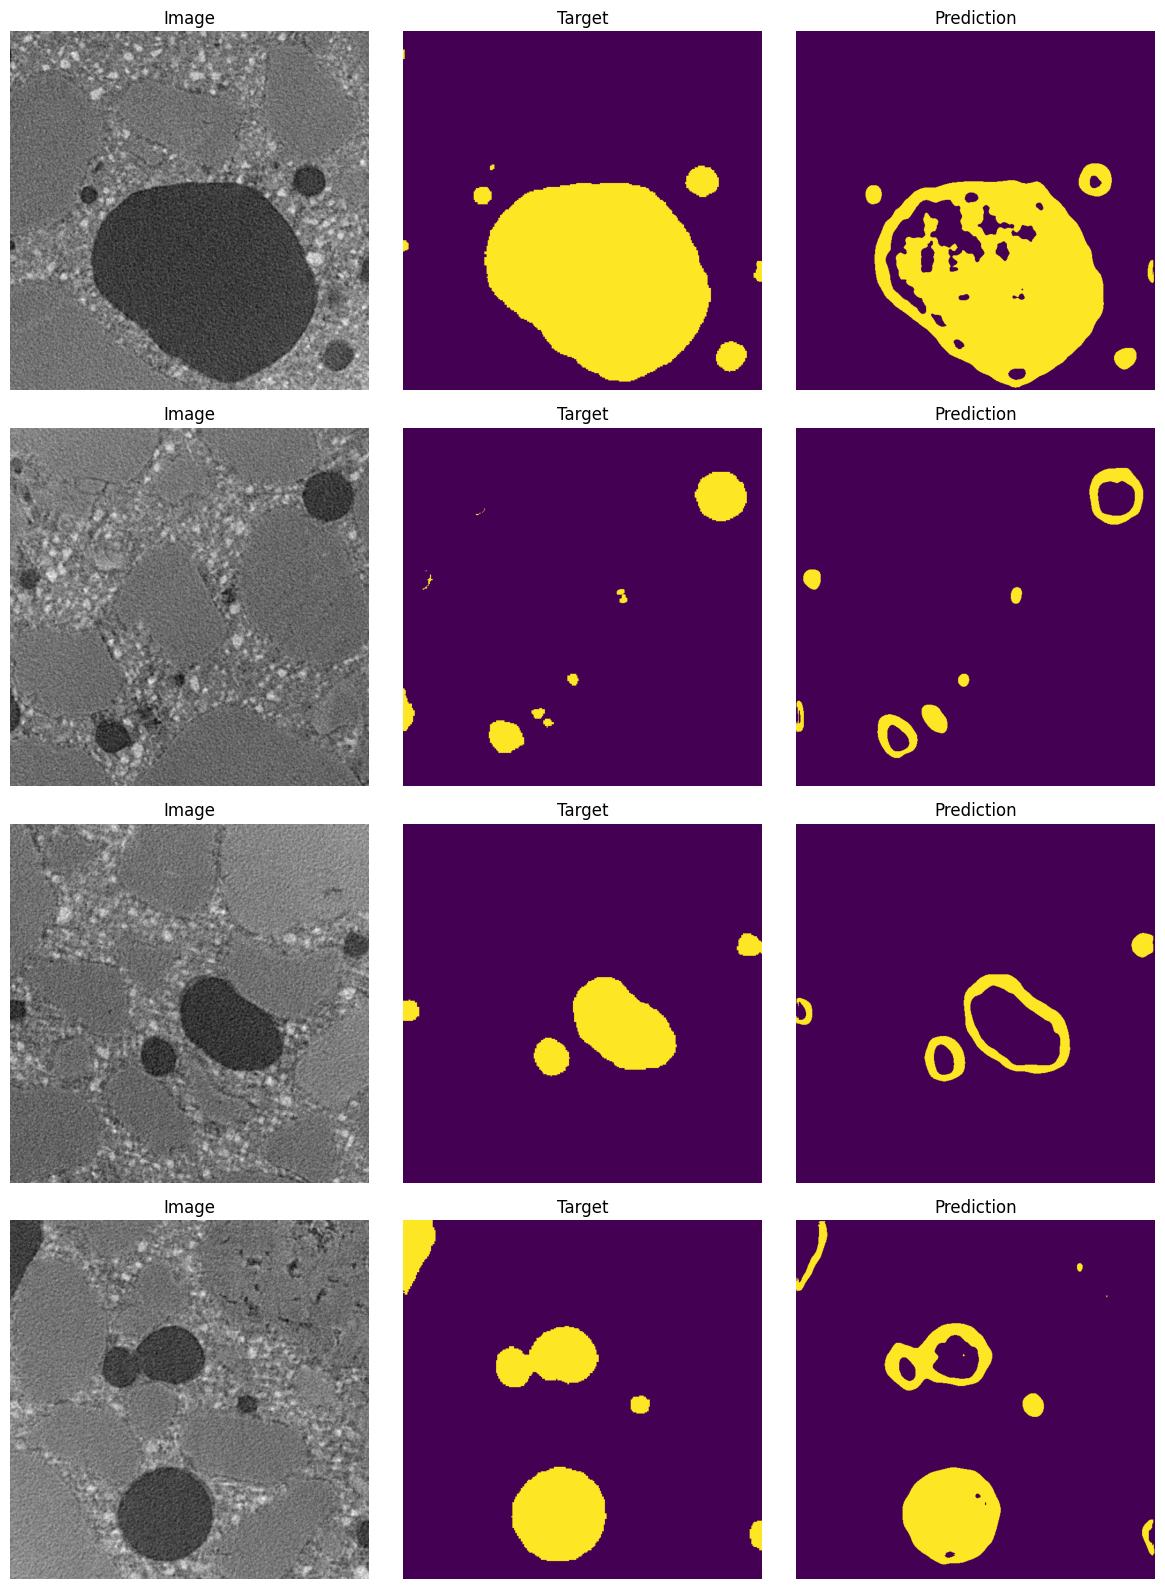

In [8]:
model.to(device)

log_dir = f"runs/DinoV2 {datetime.now().strftime('%d_%m %H_%M')}"
writer = SummaryWriter(log_dir=log_dir)

metodpisi = PCA(n_components = 2)

loss_fn = nn.BCEWithLogitsLoss()
dice_loss = my_utils.DiceLoss()   

for epoch in range(num_epochs):

    model.train()
    train_loss = 0
    for idx, batch in tqdm(enumerate(train_loader)):
        images = batch["image"].to(device)   # [B, С, H, W]
        targets = batch["target"].to(device) # [B, H, W]

        targets = targets.unsqueeze(1)
        targets = F.interpolate(targets, [640, 640], mode = 'nearest-exact')
        targets = targets.squeeze(1)

        pred = model(images).predicted_depth

        loss = loss_fn(pred, targets)# + dice_loss(pred.unsqueeze(1), targets.unsqueeze(1)) #+ 0.1 * my_utils.PR_loss(pred, targets)

        train_loss += loss.item() / batch_size

        loss.backward()
        
        optimizer.step()
        optimizer.zero_grad()
            
    train_loss /= len(train_loader)
    
    #Дичайшая валидация

    model.eval()

    val_loss = 0
    val_IoU = 0 
    val_PRAUC = 0

    for idx, batch in tqdm(enumerate(validation_loader)):
        images = batch["image"].to(device)   # [B, С, H, W]
        targets = batch["target"].to(device) # [B, H, W]

        targets = targets.unsqueeze(1)
        targets = F.interpolate(targets, [640, 640], mode = 'nearest-exact')
        targets = targets.squeeze(1)
        
        with torch.no_grad():
            pred = model(images).predicted_depth

        loss = loss_fn(pred, targets)# + dice_loss(pred.unsqueeze(1), targets.unsqueeze(1)) #+ 0.1 * my_utils.PR_loss(pred, targets)

        val_loss += loss / batch_size

        val_IoU += my_utils.compute_miou(torch.where(pred > 0.5, 1, 0).unsqueeze(1), targets, num_classes = 1)

        val_PRAUC += my_utils.pr_auc_score(pred, targets)

        if idx % 5 == 0:
            B = images.size(0)
            fig, axes = plt.subplots(B, 3, figsize=(12, 4 * B))
            for j in range(B):
                img = images[j][0].squeeze().cpu().numpy()
                gt = targets[j].cpu().numpy()
                pr = pred[j].cpu().numpy().squeeze() > 0.5

                axes[j, 0].imshow(img, cmap='gray')
                axes[j, 0].set_title("Image")
                axes[j, 0].axis('off')

                axes[j, 1].imshow(gt, cmap='viridis')
                axes[j, 1].set_title("Target")
                axes[j, 1].axis('off')

                axes[j, 2].imshow(pr, cmap='viridis')
                axes[j, 2].set_title("Prediction")
                axes[j, 2].axis('off')

            plt.tight_layout()

            writer.add_figure(f'Val/Compare_batch{idx // 5}', fig, epoch)
            plt.close(fig)

    val_IoU /= len(validation_loader)
    val_loss /= len(validation_loader)
    val_PRAUC /= len(validation_loader)


    print(f'Epoch {epoch}')
    print(f'Train loss {train_loss:.4f}')
    print(f'Validation loss {val_loss:.4f}')
    print(f'Validation IoU {val_IoU:.4f}')
    print(f'Validation AUC PR {val_PRAUC:.4f}')
    writer.add_scalar('Loss/Train', train_loss, epoch)
    writer.add_scalar('Loss/Validation', val_loss, epoch)
    writer.add_scalar('IoU', val_IoU, epoch)
    writer.add_scalar('AUC PR', val_PRAUC, epoch)
    writer.flush()

    if epoch < warmup_epochs:
        warmup_scheduler.step()
    else:
        plateau_scheduler.step(val_loss)  
writer.close()

In [ ]:
pred.predicted_depth.shape

torch.Size([8, 288, 288])

In [ ]:
pred.shape

torch.Size([4, 640, 640])

In [ ]:
targets.shape

torch.Size([4, 640, 640])